## Preprocessing

In [ ]:
# --- Prepare tensors and model
# (loads CSVs, builds per-sample PyG Dataset with correct train/val/test split)
#
# Changes vs v2:
#   5. Bidirectionality check added after loading edge_index — converts directed
#      graph to undirected using to_undirected(), saves updated topology back to
#      edge_index.json so inference uses the same bidirectional topology.
#   6. num_edges_raw introduced to distinguish CSV row count (120) from the
#      bidirectional edge count (240) — sample validation checks against raw count
#      to avoid false ValueError on every sample.
#   7. build_sample() uses num_edges_raw for the duplication condition, making the
#      intent explicit: duplicate edge_attr and y only when bidirectional conversion
#      actually happened.
#   8. Duplicate json import removed (was imported at top and again in topology block).
#   9. data_inspection flag guards the optional data analysis block.

import json
import torch
import config
import pandas as pd
from pathlib import Path
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_undirected
from c21_surrogate_model_v4 import create_model, FocalLoss

edge_csv = "v5_edge_C12_S9999_D20260430"
node_csv = "v5_node_C12_S9999_D20260430"

node_csv_path = config.GH_DATA_PATH / f"{node_csv}.csv"
edge_csv_path = config.GH_DATA_PATH / f"{edge_csv}.csv"

nodes_df = pd.read_csv(node_csv_path)
edges_df = pd.read_csv(edge_csv_path)

data_inspection = False

# ============================================================================
# TOPOLOGY
# ============================================================================

edge_index_path = Path(config.DATA_IO_PATH) / "edge_index.json"
if not edge_index_path.exists():
    raise FileNotFoundError(
        f"edge_index.json not found at {edge_index_path}. Provide a valid topology file."
    )
with open(edge_index_path, "r") as f:
    edge_index_list = json.load(f)
edge_index = torch.tensor(edge_index_list, dtype=torch.long)

if edge_index.ndim != 2 or edge_index.shape[0] != 2:
    raise ValueError(
        f"edge_index must have shape [2, num_edges], got {tuple(edge_index.shape)}"
    )

# num_edges_raw = CSV rows per sample (120).
# Kept separate from num_edges so sample validation compares against the right count.
num_edges_raw      = int(edge_index.shape[1])
expected_num_nodes = int(edge_index.max().item()) + 1
print(f"Topology loaded: {num_edges_raw} edges, expecting {expected_num_nodes} nodes per sample.")

# ============================================================================
# BIDIRECTIONALITY CHECK
# Convert to undirected if any edge is missing its reverse direction.
# In a truss, member AB == member BA — forces propagate both ways.
# ============================================================================

src, dst  = edge_index[0], edge_index[1]
forward   = set(zip(src.tolist(), dst.tolist()))
backward  = set(zip(dst.tolist(), src.tolist()))
missing   = forward - backward

if len(missing) > 0:
    print(f"Graph is directed: {num_edges_raw} edges, "
          f"{len(missing)} reverse edges missing. Converting to undirected.")
    edge_index = to_undirected(edge_index)
    print(f"Bidirectional edge_index: {edge_index.shape[1]} edges.")
    # Save updated topology so inference uses the same bidirectional graph
    with open(edge_index_path, "w") as f:
        json.dump(edge_index.tolist(), f)
    print(f"Bidirectional edge_index saved to {edge_index_path}")
else:
    print(f"Graph already undirected: {num_edges_raw} edges. No conversion needed.")

# num_edges = total edges after bidirectional conversion (240 if converted, 120 if not)
num_edges = int(edge_index.shape[1])

# ============================================================================
# COLUMN VALIDATION
# ============================================================================

node_cols = ["x", "y", "z", "Tx", "Ty", "Tz", "Rx", "Ry", "Rz", "Fz"]
edge_cols = ["Area", "Length", "E", "Iy", "Iz", "J", "EA/L"]

missing_node_cols = [c for c in node_cols if c not in nodes_df.columns]
if missing_node_cols:
    raise KeyError(
        f"Missing required node columns: {missing_node_cols}. "
        f"Please provide these columns in {node_csv_path}."
    )

missing_edge_cols = [c for c in edge_cols if c not in edges_df.columns]
if missing_edge_cols:
    raise KeyError(
        f"Missing required edge columns: {missing_edge_cols}. "
        f"Please provide these columns in {edge_csv_path}."
    )

if "Utilization" not in edges_df.columns:
    raise KeyError(
        f"Missing required target column 'Utilization' in {edge_csv_path}."
    )

# ============================================================================
# SAMPLE ID DETECTION
# ============================================================================

sample_id_col = None
for col in ("sample_id", "Sample_ID", "SampleId"):
    if col in nodes_df.columns and col in edges_df.columns:
        sample_id_col = col
        break

if sample_id_col is None:
    raise KeyError(
        "No sample ID column found in CSVs. "
        "Expected one of: 'sample_id', 'Sample_ID', 'SampleId'. "
        "Ensure both node and edge CSVs contain the same sample ID column."
    )

print(f"Sample ID column detected: '{sample_id_col}'")

# ============================================================================
# SAMPLE VALIDATION
# Compare against num_edges_raw (CSV rows = 120), NOT num_edges (240 after
# bidirectional conversion). The duplication happens in build_sample(), not here.
# ============================================================================

node_groups = nodes_df.groupby(sample_id_col)
edge_groups = edges_df.groupby(sample_id_col)
samples = sorted(
    set(node_groups.groups.keys()).intersection(edge_groups.groups.keys())
)
if not samples:
    raise ValueError("No matching sample IDs between node and edge CSVs.")

print(f"Found {len(samples)} matching samples.")

for s in samples:
    n_count = len(node_groups.get_group(s))
    e_count = len(edge_groups.get_group(s))
    if n_count != expected_num_nodes:
        raise ValueError(
            f"Sample {s}: node count {n_count} != expected {expected_num_nodes}"
        )
    if e_count != num_edges_raw:    # intentionally num_edges_raw, not num_edges
        raise ValueError(
            f"Sample {s}: edge count {e_count} != expected {num_edges_raw} "
            f"(raw CSV count, before bidirectional duplication)"
        )

# ============================================================================
# TRAIN / VAL / TEST SPLIT
# Performed BEFORE computing normalisation statistics to prevent data leakage.
# ============================================================================

torch.manual_seed(42)
shuffled   = torch.randperm(len(samples)).tolist()
train_size = int(0.8 * len(samples))
val_size   = int(0.1 * len(samples))

train_indices = shuffled[:train_size]
val_indices   = shuffled[train_size:train_size + val_size]
test_indices  = shuffled[train_size + val_size:]

train_samples = [samples[i] for i in train_indices]
val_samples   = [samples[i] for i in val_indices]
test_samples  = [samples[i] for i in test_indices]

print(f"Split: Train={len(train_samples)} | Val={len(val_samples)} | Test={len(test_samples)}")

# ============================================================================
# NORMALISATION
# Statistics computed from training rows only — applied to all splits.
# ============================================================================

train_nodes = nodes_df[nodes_df[sample_id_col].isin(train_samples)]
train_edges = edges_df[edges_df[sample_id_col].isin(train_samples)]

node_feature_means = train_nodes[node_cols].mean()
node_feature_stds  = train_nodes[node_cols].std(ddof=0).replace(0, 1.0)
edge_feature_means = train_edges[edge_cols].mean()
edge_feature_stds  = train_edges[edge_cols].std(ddof=0).replace(0, 1.0)

print("Normalisation statistics computed from training data only (z-score, clipped to ±5 sigma).")

norm_stats = {
    "node_means": node_feature_means.to_dict(),
    "node_stds":  node_feature_stds.to_dict(),
    "edge_means": edge_feature_means.to_dict(),
    "edge_stds":  edge_feature_stds.to_dict(),
    "node_cols":  node_cols,
    "edge_cols":  edge_cols,
}
norm_stats_path = Path(config.DATA_IO_PATH) / "norm_stats.pt"
torch.save(norm_stats, norm_stats_path)
print(f"Normalisation stats saved to {norm_stats_path}")

# ============================================================================
# CLASS BALANCE
# Computed from training edges only to prevent leakage into focal_alpha.
# ============================================================================

train_pos_rate = float((train_edges["Utilization"] > 1).mean())
focal_alpha    = float(max(0.05, min(0.95, 1.0 - train_pos_rate)))
print(f"Train positive rate (Utilization>1): {train_pos_rate:.4f} -> focal_alpha={focal_alpha:.4f}")

# ============================================================================
# DATASET CONSTRUCTION
# ============================================================================

def build_sample(s, node_groups, edge_groups):
    """
    Build a single PyG Data object for sample s.

    edge_attr and y are duplicated when the graph was made bidirectional
    (num_edges == 2 * num_edges_raw). Reverse edges share the same physical
    properties and utilization as their forward counterparts.
    """
    n_df = node_groups.get_group(s)
    e_df = edge_groups.get_group(s)

    x = torch.tensor(
        ((n_df[node_cols] - node_feature_means) / node_feature_stds)
        .clip(-5, 5).values,
        dtype=torch.float32,
    )

    edge_attr_norm = torch.tensor(
        ((e_df[edge_cols] - edge_feature_means) / edge_feature_stds)
        .clip(-5, 5).values,
        dtype=torch.float32,
    )

    y_vals = torch.tensor(
        (e_df["Utilization"] > 1).astype(int).values,
        dtype=torch.float32,
    )

    # Duplicate for reverse edges only if bidirectional conversion happened
    if num_edges == 2 * num_edges_raw:
        edge_attr_norm = torch.cat([edge_attr_norm, edge_attr_norm], dim=0)
        y_vals         = torch.cat([y_vals, y_vals], dim=0)

    return Data(
        x=x,
        edge_index=edge_index.clone(),
        edge_attr=edge_attr_norm,
        y=y_vals.view(-1, 1),
    )


train_dataset = [build_sample(s, node_groups, edge_groups) for s in train_samples]
val_dataset   = [build_sample(s, node_groups, edge_groups) for s in val_samples]
test_dataset  = [build_sample(s, node_groups, edge_groups) for s in test_samples]

print(
    f"Dataset constructed: {len(train_dataset)} train | "
    f"{len(val_dataset)} val | {len(test_dataset)} test samples. "
    f"Each sample: {expected_num_nodes} nodes, {num_edges} edges "
    f"({'bidirectional' if num_edges == 2 * num_edges_raw else 'undirected as loaded'})."
)

# ============================================================================
# MODEL
# ============================================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = create_model(
    node_features_dim=len(node_cols),
    edge_features_dim=len(edge_cols),
    device=device,
)
model.to(device)
print(
    f"Model on {device} | "
    f"node_features_dim={len(node_cols)} | edge_features_dim={len(edge_cols)}"
)

# ============================================================================
# DATALOADERS
# ============================================================================

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(
    f"DataLoaders ready — "
    f"Train: {len(train_dataloader)} batches | "
    f"Val: {len(val_dataloader)} batches | "
    f"Test: {len(test_dataloader)} batches "
    f"(batch_size={batch_size})"
)

# ============================================================================
# LOSS
# ============================================================================

loss_fn = FocalLoss(alpha=focal_alpha, gamma=2.0)
print(f"FocalLoss(alpha={focal_alpha:.4f}, gamma=2.0)")

# ============================================================================
# DATA INSPECTION (optional — set data_inspection = True to enable)
# ============================================================================

if data_inspection:
    unsafe_per_sample = edges_df.groupby(sample_id_col).apply(
        lambda g: (g["Utilization"] > 1).sum()
    )
    print(unsafe_per_sample.describe())
    print(unsafe_per_sample.value_counts().sort_index().head(20))

    zero_unsafe = edges_df.groupby(sample_id_col).apply(
        lambda g: (g["Utilization"] > 1).sum() == 0
    )
    zero_ids = zero_unsafe[zero_unsafe].index
    print(edges_df[edges_df[sample_id_col].isin(zero_ids)][edge_cols].describe())

# ============================================================================
# READY — objects available for training loop:
#   model, loss_fn, train_dataloader, val_dataloader, test_dataloader, device
#   num_edges_raw  (120 — physical members, for per-member analysis in evaluation)
#   num_edges      (240 if bidirectional, else 120)
#
# NOTE: evaluation script NUM_EDGES should be set to num_edges_raw (120)
# for per-member analysis — the second 120 reverse edges are statistical
# duplicates and can be sliced off with [:num_edges_raw].
# ============================================================================

System loaded successfully.

Code is running locally from: thesis_generative_timber
Data connected to OneDrive: 2.2 - 2.4

GH data directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\02_grasshopper_data
Geometry data directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\01_geometry_data
Export directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports



c:\Users\Jasper\Documents\PyEnvs\thesis_home_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Topology: 120 edges, expecting 39 nodes per sample.
Sample ID column detected: 'Sample_ID'
Found 10000 matching samples.
Split: Train=8000 | Val=1000 | Test=1000
Normalisation statistics computed from training data only (z-score, clipped to ±5 sigma).
Normalisation stats saved to C:\Users\Jasper\Documents\PyRepo\thesis_generative_timber\02_data_io\norm_stats.pt
Train positive rate (Utilization>1): 0.1899 -> focal_alpha=0.8101
Dataset constructed: 8000 train | 1000 val | 1000 test samples. Each sample: 39 nodes, 120 edges.
Model on cuda | node_features_dim=10 | edge_features_dim=7
DataLoaders ready — Train: 250 batches | Val: 32 batches | Test: 32 batches (batch_size=32)
FocalLoss(alpha=0.8101, gamma=2.0)


## Training

In [ ]:
# --- Training loop (follows c21_preprocessing_v2.py) ---
#
# Requires from preprocessing: model, loss_fn, train_dataloader, val_dataloader,
#                              test_dataloader, train_dataset, val_dataset,
#                              test_dataset, device, focal_alpha
#
# Improvements vs v1:
#   1. ReduceLROnPlateau scheduler — halves LR when val loss plateaus
#   2. Gradient clipping (max_norm=1.0) — prevents exploding gradients in NNConv
#   3. Early stopping with configurable patience — stops when val loss stops improving
#   4. Classification metrics at eval: recall, precision, F1, AUC-ROC, confusion matrix
#   5. Threshold sweep on val set to find the operating point that maximises recall
#      while keeping precision acceptable — result used for test evaluation
#   6. BCELoss option removed; FocalLoss with data-driven focal_alpha is always used
#   7. Checkpoint filename versioned to v4

import numpy as np
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

# ============================================================================
# HYPERPARAMETERS
# ============================================================================

EPOCHS          = 150
LR              = 3e-4
PATIENCE        = 40       # early stopping: stop if val loss doesn't improve for this many epochs
LR_FACTOR       = 0.5      # ReduceLROnPlateau: multiply LR by this on plateau
LR_PATIENCE     = 10       # ReduceLROnPlateau: epochs to wait before reducing LR
LR_MIN          = 1e-6     # minimum LR floor
GRAD_CLIP       = 1.0      # max gradient norm (set None to disable)
CKPT_PATH       = "surrogate_v4_checkpoint.pth"
focal_alpha     = 0.5 # from preprocessing, data-driven from train positive rate
experiment_mode = False

# Decision threshold: values below 0.5 bias toward catching unsafe members
# (false negatives are more dangerous than false positives in structural safety).
# We sweep the val set to find the best threshold, but this is the fallback.
DEFAULT_THRESHOLD = 0.35

# print(f"\nHyperparameters:")
print(f"Hyperparameters:")
print(f"  EPOCHS: {EPOCHS}")
print(f"  LR: {LR}")
print(f"  PATIENCE: {PATIENCE}")
print(f"  LR_FACTOR: {LR_FACTOR}")
print(f"  LR_PATIENCE: {LR_PATIENCE}")
print(f"  LR_MIN: {LR_MIN}")
print(f"  GRAD_CLIP: {GRAD_CLIP}")
print(f"  CKPT_PATH: {CKPT_PATH}")
print(f"  focal_alpha: {focal_alpha}")
print(f"  DEFAULT_THRESHOLD: {DEFAULT_THRESHOLD}")

# ============================================================================
# OPTIMIZER, SCHEDULER, LOSS
# ============================================================================

#optimizer = torch.optim.Adam(model.parameters(), lr=LR)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=LR_MIN,
)

# focal_alpha comes from preprocessing (data-driven from train positive rate)
loss_fn = FocalLoss(alpha=focal_alpha, gamma=2.0)
print(f"FocalLoss(alpha={focal_alpha:.4f}, gamma=2.0)")

# ============================================================================
# EXPERIMENT
# ============================================================================
# iterate of different loss configurations and compare val AUC after 20 epochs

loss_functions = {
    "FocalLoss (data-driven)": FocalLoss(alpha=focal_alpha, gamma=2.0),
    "FocalLoss (moderate)":   FocalLoss(alpha=0.50, gamma=2.0),
    "BCELoss":                torch.nn.BCELoss(),
}

# ============================================================================
# TRAINING LOOP
# ============================================================================

train_losses  = []
val_losses    = []
epoch_history = []

best_val_loss = float("inf")
best_state    = None
best_epoch    = -1
epochs_no_improve = 0

print(f"\nStarting training: {EPOCHS} epochs, early stopping patience={PATIENCE}")
print("-" * 70)

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model.train()
    epoch_train_loss = 0.0

    for batch in train_dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()
        preds = model(batch.x, batch.edge_index, batch.edge_attr)
        loss  = loss_fn(preds, batch.y)
        loss.backward()

        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

        optimizer.step()
        epoch_train_loss += loss.item() * batch.num_graphs

    epoch_train_loss /= len(train_dataset)
    train_losses.append(epoch_train_loss)

    # ---- VALIDATE ----
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for batch in val_dataloader:
            batch = batch.to(device)
            preds = model(batch.x, batch.edge_index, batch.edge_attr)
            loss  = loss_fn(preds, batch.y)
            epoch_val_loss += loss.item() * batch.num_graphs

    epoch_val_loss /= len(val_dataset)
    val_losses.append(epoch_val_loss)

    # Step scheduler on val loss
    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # ---- CHECKPOINT ----
    if epoch_val_loss < best_val_loss:
        best_val_loss = float(epoch_val_loss)
        best_epoch    = int(epoch)
        best_state    = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # ---- LOGGING (every 5 epochs) ----
    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:03d}  "
            f"train={epoch_train_loss:.6f}  "
            f"val={epoch_val_loss:.6f}  "
            f"lr={current_lr:.2e}  "
            f"no_improve={epochs_no_improve}/{PATIENCE}"
        )
        epoch_history.append((epoch + 1, epoch_train_loss, epoch_val_loss, current_lr))

    # ---- EARLY STOPPING ----
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch + 1} (no improvement for {PATIENCE} epochs).")
        break

print("-" * 70)

# ============================================================================
# RESTORE BEST CHECKPOINT
# ============================================================================

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Restored best checkpoint from epoch {best_epoch + 1}  val_loss={best_val_loss:.6f}")
else:
    print("Warning: best_state was not set; using last epoch weights.")

# ============================================================================
# SAVE CHECKPOINT
# ============================================================================

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "best_val_loss":    best_val_loss,
        "best_epoch":       best_epoch,
        "focal_alpha":      focal_alpha,
        "train_losses":     train_losses,
        "val_losses":       val_losses,
    },
    CKPT_PATH,
)
print(f"Checkpoint saved: {CKPT_PATH}")


# ============================================================================
# HELPER: collect predictions from a dataloader
# ============================================================================

def collect_preds(dataloader, model, device):
    """Returns (probs, targets) as flat numpy arrays."""
    model.eval()
    all_probs   = []
    all_targets = []
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            probs = model(batch.x, batch.edge_index, batch.edge_attr)
            all_probs.append(probs.cpu())
            all_targets.append(batch.y.cpu())
    probs   = torch.cat(all_probs,   dim=0).view(-1).numpy()
    targets = torch.cat(all_targets, dim=0).view(-1).numpy()
    return probs, targets


def classification_report_at_threshold(probs, targets, threshold, label=""):
    """Print confusion matrix + classification report at a given threshold."""
    preds_binary = (probs >= threshold).astype(int)
    cm = confusion_matrix(targets.astype(int), preds_binary)
    print(f"\n{'='*60}")
    print(f"{label}  (threshold={threshold:.2f})")
    print(f"{'='*60}")
    print(f"Confusion matrix (rows=actual, cols=predicted):")
    print(f"              Pred Safe  Pred Unsafe")
    print(f"  Act Safe    {cm[0,0]:9d}  {cm[0,1]:11d}")
    print(f"  Act Unsafe  {cm[1,0]:9d}  {cm[1,1]:11d}")
    print()
    print(classification_report(
        targets.astype(int), preds_binary,
        target_names=["Safe (0)", "Unsafe (1)"],
        digits=4,
    ))
    recall_unsafe    = recall_score(targets, preds_binary, pos_label=1, zero_division=0)
    precision_unsafe = precision_score(targets, preds_binary, pos_label=1, zero_division=0)
    f1_unsafe        = f1_score(targets, preds_binary, pos_label=1, zero_division=0)
    print(f"Unsafe class  ->  Recall: {recall_unsafe:.4f}  Precision: {precision_unsafe:.4f}  F1: {f1_unsafe:.4f}")
    return recall_unsafe, precision_unsafe, f1_unsafe


# ============================================================================
# THRESHOLD SWEEP ON VALIDATION SET
# Finds the threshold that maximises recall on the unsafe class while keeping
# precision >= min_precision. For structural safety, catching failures matters
# more than avoiding false alarms.
# ============================================================================

print("\n--- Threshold sweep on validation set ---")
val_probs, val_targets = collect_preds(val_dataloader, model, device)

try:
    val_auc = roc_auc_score(val_targets, val_probs)
    print(f"Val AUC-ROC: {val_auc:.4f}")
except ValueError:
    print("Val AUC-ROC: n/a (only one class present in val targets)")
    val_auc = None

thresholds    = np.arange(0.10, 0.65, 0.05)
min_precision = 0.40   # lower bound: accept some false alarms to catch failures
best_threshold = DEFAULT_THRESHOLD
best_recall    = -1.0

sweep_results = []
for t in thresholds:
    preds_bin     = (val_probs >= t).astype(int)
    recall_u      = recall_score(val_targets, preds_bin, pos_label=1, zero_division=0)
    precision_u   = precision_score(val_targets, preds_bin, pos_label=1, zero_division=0)
    f1_u          = f1_score(val_targets, preds_bin, pos_label=1, zero_division=0)
    sweep_results.append((t, recall_u, precision_u, f1_u))
    if recall_u > best_recall and precision_u >= min_precision:
        best_recall    = recall_u
        best_threshold = t

print(f"\n{'Threshold':>10}  {'Recall(unsafe)':>15}  {'Precision(unsafe)':>18}  {'F1(unsafe)':>12}")
print("-" * 62)
for t, r, p, f in sweep_results:
    marker = " <-- selected" if abs(t - best_threshold) < 1e-6 else ""
    print(f"{t:10.2f}  {r:15.4f}  {p:18.4f}  {f:12.4f}{marker}")

print(f"\nSelected threshold: {best_threshold:.2f}  "
      f"(max recall >= {min_precision:.0%} precision constraint)")

# Full report on val set at chosen threshold
classification_report_at_threshold(val_probs, val_targets, best_threshold, label="VALIDATION SET")

# ============================================================================
# TEST SET EVALUATION
# ============================================================================

print("\n--- Test set evaluation ---")
test_probs, test_targets = collect_preds(test_dataloader, model, device)

try:
    test_auc = roc_auc_score(test_targets, test_probs)
    print(f"Test AUC-ROC: {test_auc:.4f}")
except ValueError:
    print("Test AUC-ROC: n/a (only one class present in test targets)")
    test_auc = None

# Evaluate at the threshold chosen on the val set
classification_report_at_threshold(test_probs, test_targets, best_threshold, label="TEST SET")

# Also show what 0.5 looks like for reference
classification_report_at_threshold(test_probs, test_targets, 0.5, label="TEST SET (default threshold=0.50, for reference)")

# ============================================================================
# COMPUTE AND PRINT TEST LOSS
# ============================================================================

model.eval()
test_loss = 0.0
with torch.no_grad():
    for batch in test_dataloader:
        batch = batch.to(device)
        preds = model(batch.x, batch.edge_index, batch.edge_attr)
        loss  = loss_fn(preds, batch.y)
        test_loss += loss.item() * batch.num_graphs
test_loss /= len(test_dataset)
print(f"\nTest focal loss: {test_loss:.6f}")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("TRAINING SUMMARY")
print("=" * 70)
print(f"  Best epoch:       {best_epoch + 1}")
print(f"  Best val loss:    {best_val_loss:.6f}")
print(f"  Test focal loss:  {test_loss:.6f}")
if val_auc:  print(f"  Val  AUC-ROC:     {val_auc:.4f}")
if test_auc: print(f"  Test AUC-ROC:     {test_auc:.4f}")
print(f"  Decision threshold (val-tuned): {best_threshold:.2f}")
print(f"  Checkpoint: {CKPT_PATH}")
print("=" * 70)

Hyperparameters:
  EPOCHS: 100
  LR: 0.0003
  PATIENCE: 30
  LR_FACTOR: 0.5
  LR_PATIENCE: 10
  LR_MIN: 1e-06
  GRAD_CLIP: 1.0
  CKPT_PATH: surrogate_v4_checkpoint.pth
  focal_alpha: 0.5
  DEFAULT_THRESHOLD: 0.35
FocalLoss(alpha=0.5000, gamma=2.0)

Starting training: 100 epochs, early stopping patience=30
----------------------------------------------------------------------
Epoch 005  train=0.047476  val=0.046635  lr=3.00e-04  no_improve=0/30
Epoch 010  train=0.045275  val=0.046614  lr=3.00e-04  no_improve=1/30
Epoch 015  train=0.044189  val=0.043256  lr=3.00e-04  no_improve=0/30
Epoch 020  train=0.043456  val=0.042704  lr=3.00e-04  no_improve=0/30
Epoch 025  train=0.043079  val=0.042382  lr=3.00e-04  no_improve=0/30
Epoch 030  train=0.042754  val=0.042639  lr=3.00e-04  no_improve=3/30
Epoch 035  train=0.042471  val=0.042127  lr=3.00e-04  no_improve=4/30
Epoch 040  train=0.042186  val=0.042038  lr=3.00e-04  no_improve=9/30
Epoch 045  train=0.042214  val=0.042121  lr=3.00e-04  no_impro

## Evaluation

Thresholds — val-tuned: 0.350 | max-F1: 0.432 | safety (P>=40%): 0.315


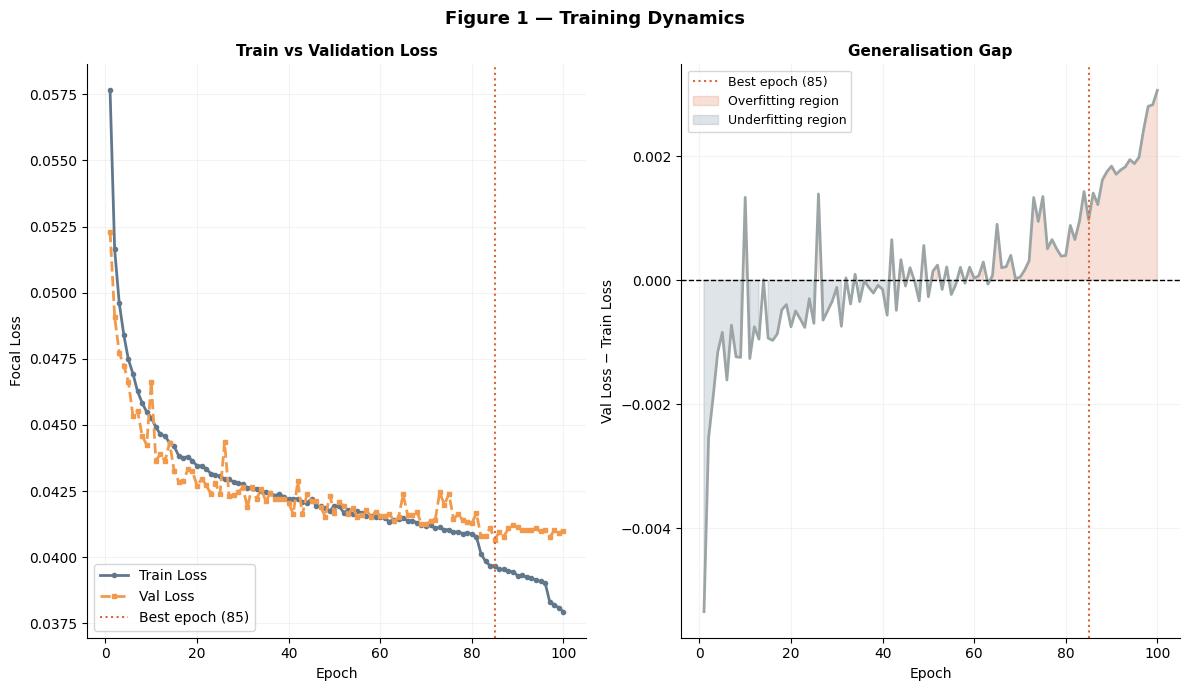

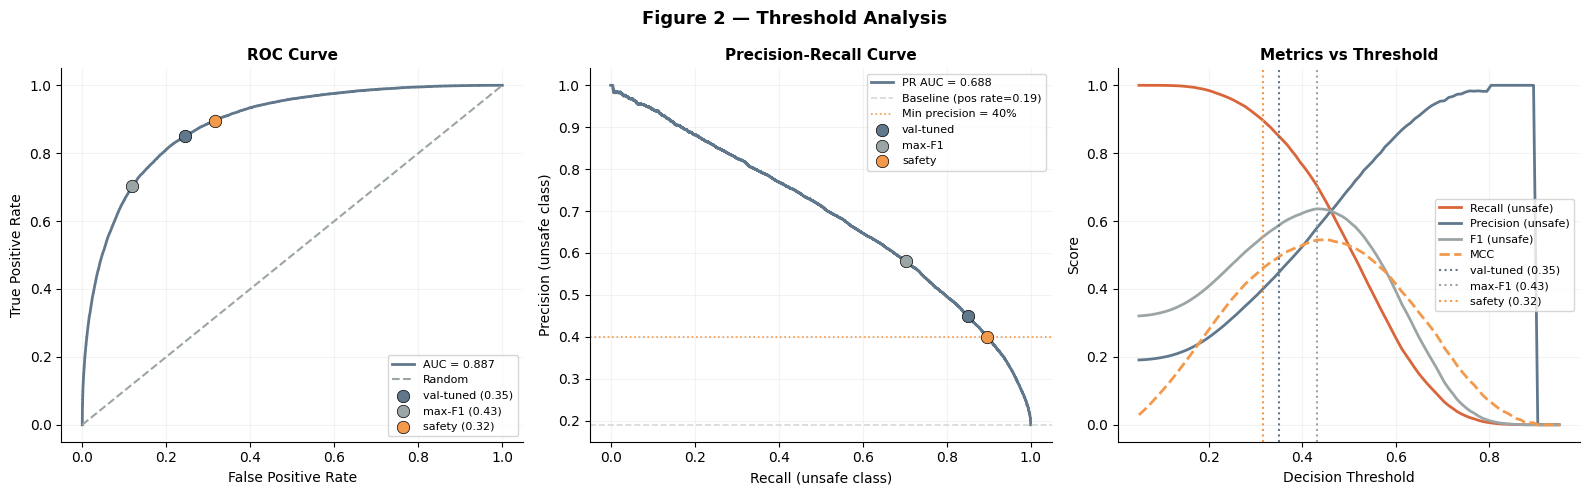

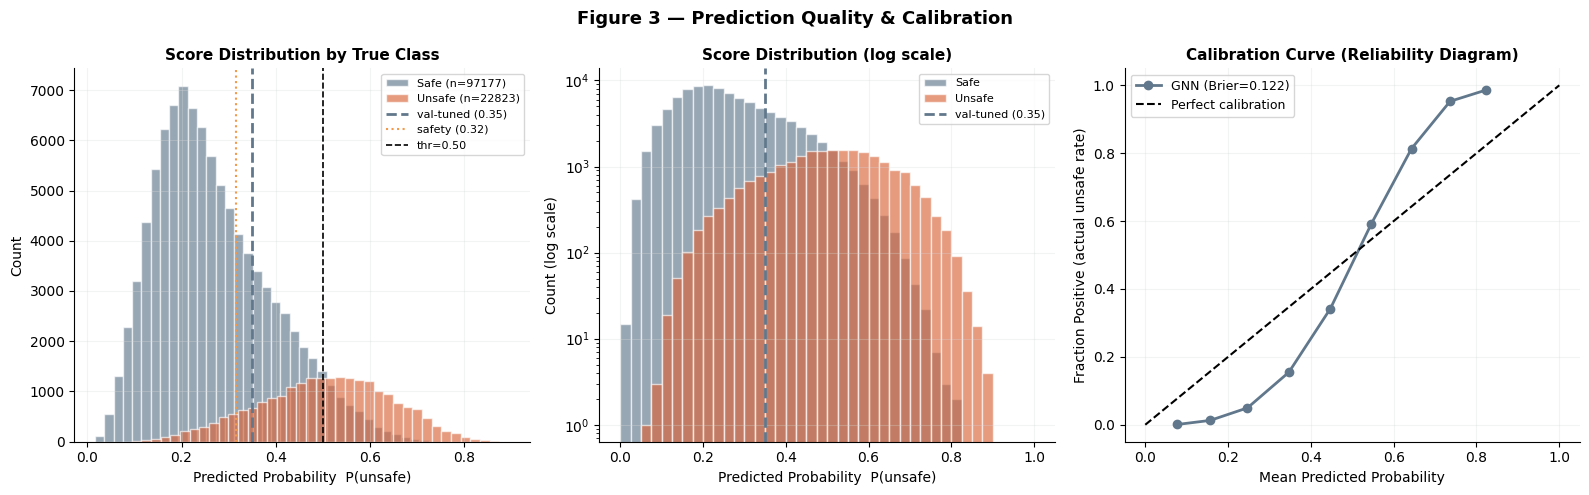

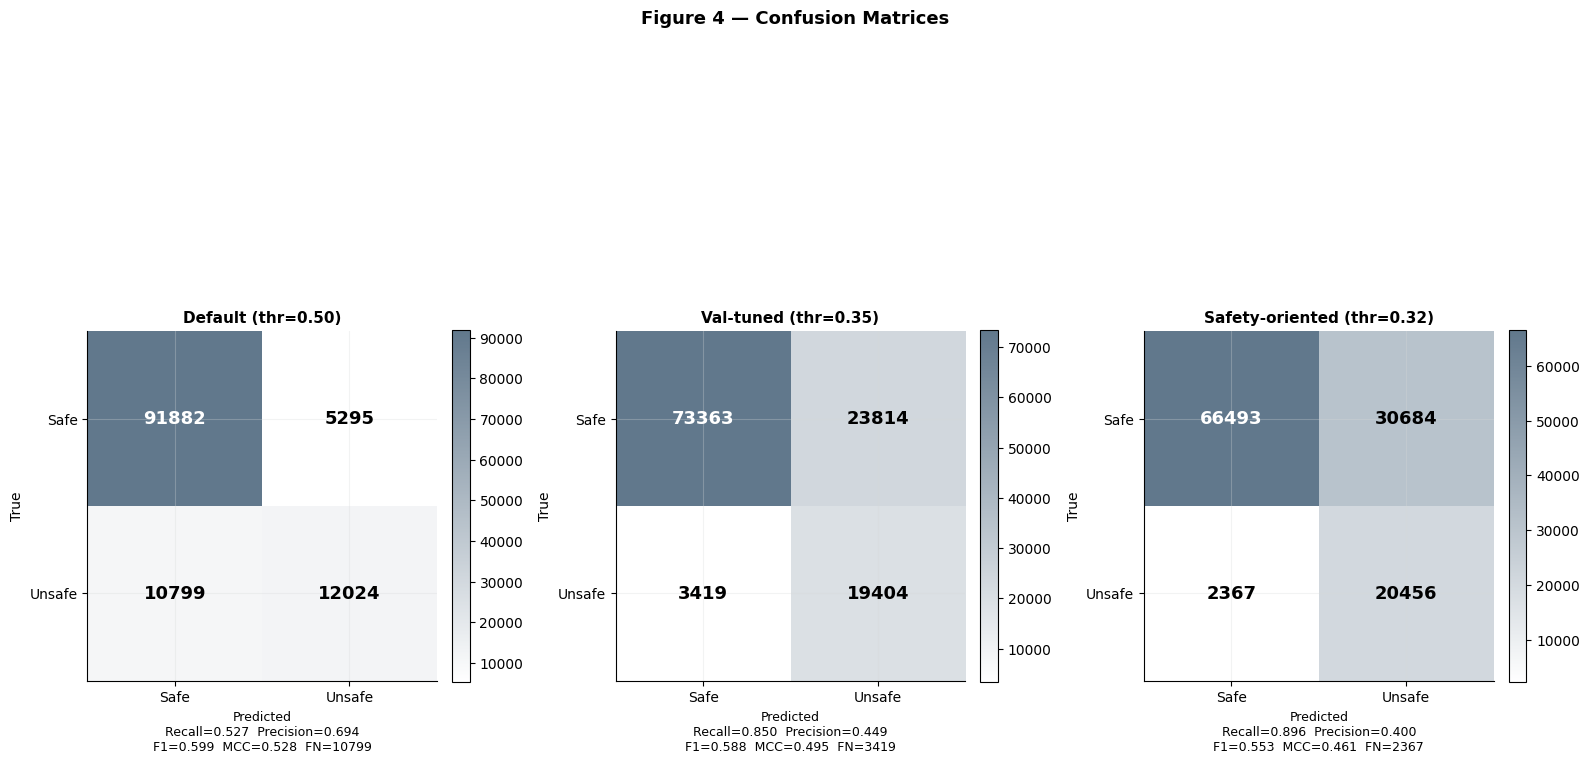

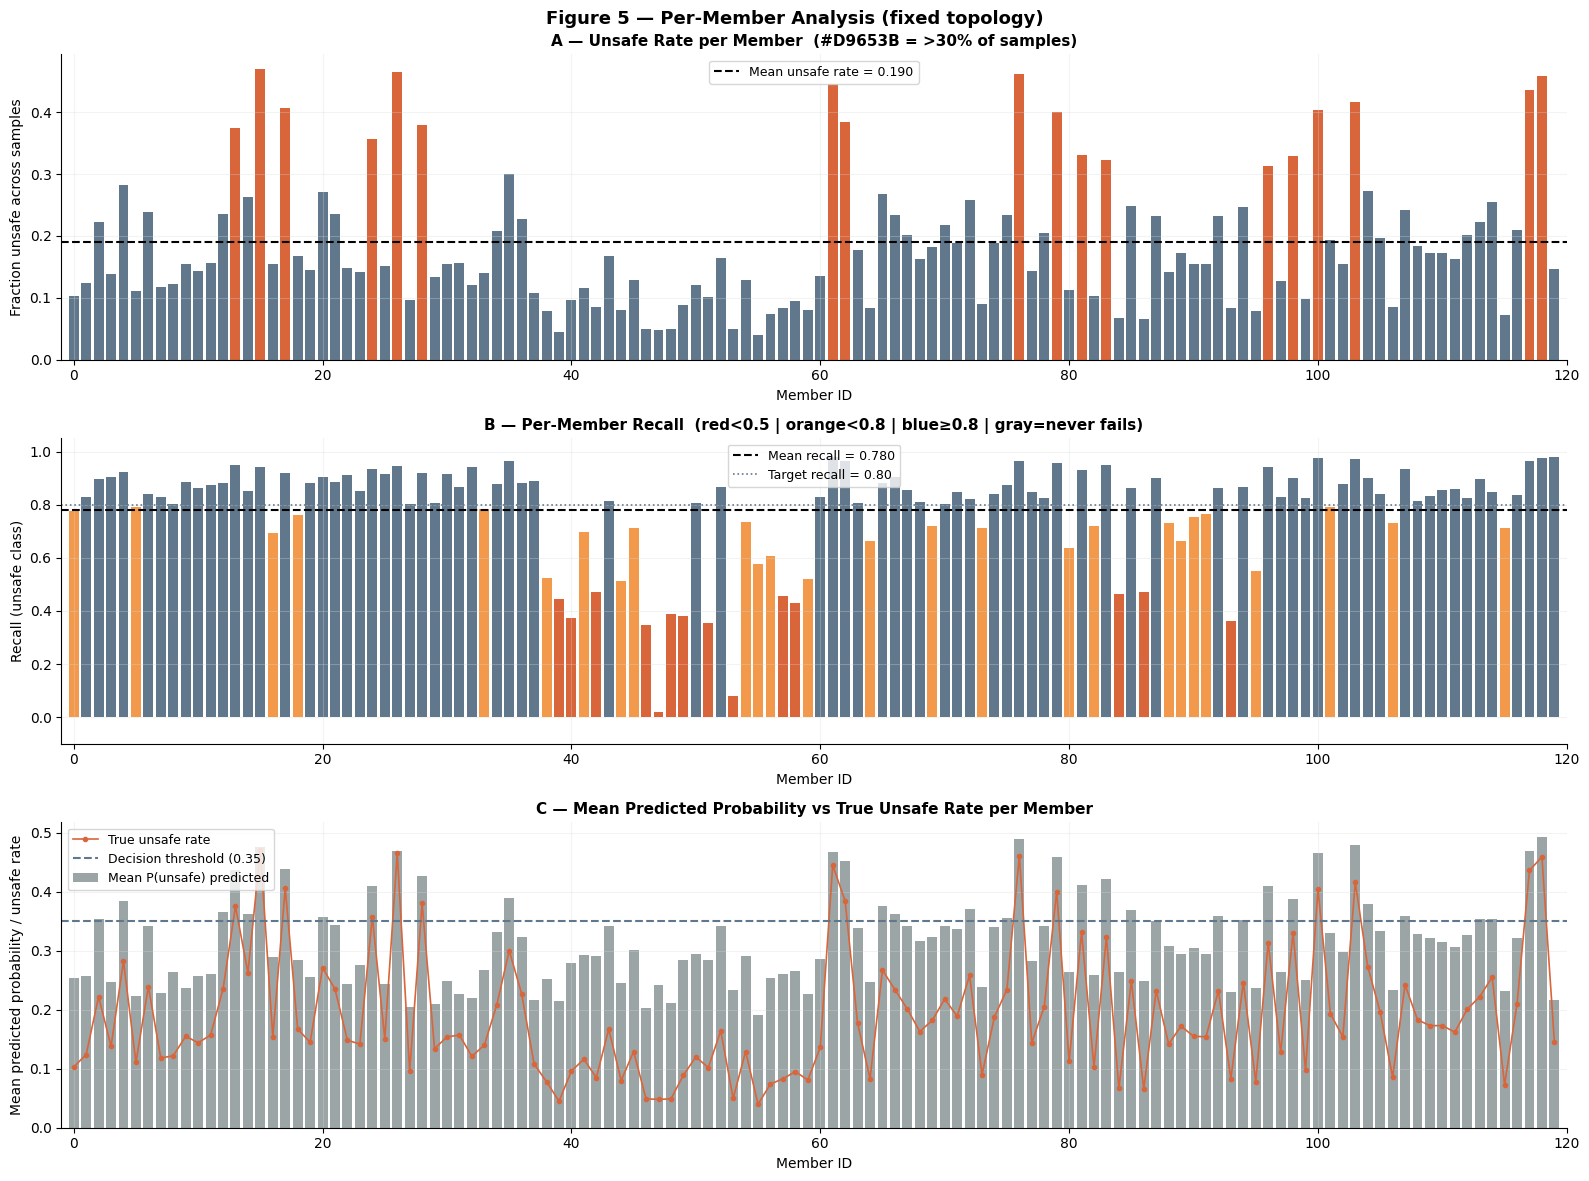


Top 10 hardest members (lowest recall among failing members):
  MemberID  UnsafeRate    Recall       FPR
        47       0.048     0.021     0.021
        53       0.050     0.080     0.023
        46       0.049     0.347     0.067
        51       0.102     0.353     0.149
        93       0.083     0.361     0.083
        40       0.096     0.375     0.126
        49       0.089     0.382     0.125
        48       0.049     0.388     0.062
        58       0.095     0.432     0.120
        39       0.045     0.444     0.047

EVALUATION SUMMARY — TrussEdgeSafetyGNN
  Epochs trained:      100  (best: 85)
  Final train loss:    0.037943
  Final val loss:      0.041008

  Threshold-independent:
    ROC AUC:    0.8873   (>0.90 = excellent, >0.80 = good)
    PR  AUC:    0.6879   (baseline = 0.190)
    Brier:      0.1220   (0 = perfect calibration)

  @ Default (thr=0.50):
    Accuracy:        0.8659
    Precision:       0.6943
    Recall (unsafe): 0.5268   <- most important for structu

In [ ]:
# =============================================================================
# Binary Classification Evaluation — TrussEdgeSafetyGNN
# =============================================================================
#
# Requires from training:
#   train_losses, val_losses      — per-epoch loss lists
#   test_probs, test_targets      — flat numpy arrays from collect_preds()
#   best_threshold                — threshold chosen on val set (from train script)
#   best_epoch                    — epoch at which best checkpoint was saved
#
# Produces:
#   fig1  — Training dynamics  (loss curves + generalisation gap)
#   fig2  — Threshold analysis (ROC, PR, metrics vs threshold sweep)
#   fig3  — Prediction quality (probability distributions + calibration)
#   fig4  — Confusion matrices (default | val-tuned | safety threshold)
#   fig5  — Per-member analysis (unsafe rate, recall, mean prob per edge)
#   metrics — dict of all scalar metrics for export cell
#
# Changes vs original:
#   - Config colours and style applied throughout (from config.PLOT_COLORS/PLOT_STYLE)
#   - P(safe) label corrected to P(unsafe) on distribution plots
#   - MIN_PRECISION raised to 0.40 (consistent with train script)
#   - Figure variables named fig1-fig5 for export cell compatibility
#   - per_edge_fpr exposed in metrics dict for downstream reporting

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    accuracy_score, auc, brier_score_loss, confusion_matrix,
    f1_score, matthews_corrcoef, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.calibration import calibration_curve
import config
from config import PLOT_COLORS as C, PLOT_STYLE as S

# =============================================================================
# 0. SETTINGS
# =============================================================================

NUM_EDGES     = 240    # fixed topology — update if truss changes
MIN_PRECISION = 0.40   # minimum precision for safety-oriented threshold

# =============================================================================
# 1. GUARD
# =============================================================================

required_vars = [
    "train_losses", "val_losses",
    "test_probs", "test_targets",
    "best_threshold", "best_epoch",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        "Missing variables from training script: "
        + ", ".join(missing)
        + ". Run c21_train_v2.py first."
    )

# =============================================================================
# 2. GLOBAL STYLE  (config palette + shared settings)
# =============================================================================

plt.rcParams.update({
    "figure.dpi":        S["dpi"],
    "axes.grid":         True,
    "grid.alpha":        S["grid_alpha"],
    "grid.color":        C["neutral"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.edgecolor":    C["black"],
    "axes.labelcolor":   C["black"],
    "xtick.color":       C["black"],
    "ytick.color":       C["black"],
    "text.color":        C["black"],
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "lines.linewidth":   S["line_width"],
    "lines.markersize":  S["marker_size"],
})

# =============================================================================
# 3. CORE METRICS
# =============================================================================

test_probs   = np.asarray(test_probs).flatten()
test_true    = np.asarray(test_targets).flatten().astype(int)
epochs_range = np.arange(1, len(train_losses) + 1)

# Curves
fpr, tpr, _                              = roc_curve(test_true, test_probs)
roc_auc                                  = roc_auc_score(test_true, test_probs)
precision_curve, recall_curve, pr_thr    = precision_recall_curve(test_true, test_probs)
pr_auc                                   = auc(recall_curve, precision_curve)

# Threshold A: maximise F1
f1_curve      = (2 * precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-12)
idx_f1        = int(np.argmax(f1_curve[:-1]))
threshold_f1  = float(pr_thr[idx_f1]) if len(pr_thr) > 0 else 0.5

# Threshold B: maximise recall on unsafe class subject to precision >= MIN_PRECISION
viable_mask = precision_curve[:-1] >= MIN_PRECISION
if viable_mask.any():
    idx_safety       = np.where(viable_mask)[0][int(np.argmax(recall_curve[:-1][viable_mask]))]
    threshold_safety = float(pr_thr[idx_safety])
else:
    threshold_safety = threshold_f1
    print(f"Warning: no threshold achieves precision >= {MIN_PRECISION:.0%}; "
          f"falling back to max-F1 threshold ({threshold_f1:.3f}).")

thr_primary = float(best_threshold)   # val-tuned threshold from training script

def scores_at(thr):
    pred           = (test_probs >= thr).astype(int)
    cm             = confusion_matrix(test_true, pred, labels=[0, 1])
    tn_, fp_, fn_, tp_ = cm.ravel()
    return dict(
        threshold = thr, pred=pred, cm=cm,
        tn=int(tn_), fp=int(fp_), fn=int(fn_), tp=int(tp_),
        accuracy  = accuracy_score(test_true, pred),
        precision = precision_score(test_true, pred, zero_division=0),
        recall    = recall_score(test_true, pred, zero_division=0),
        f1        = f1_score(test_true, pred, zero_division=0),
        mcc       = matthews_corrcoef(test_true, pred),
    )

s_05      = scores_at(0.5)
s_primary = scores_at(thr_primary)
s_f1      = scores_at(threshold_f1)
s_safety  = scores_at(threshold_safety)
brier     = brier_score_loss(test_true, test_probs)

print(f"Thresholds — val-tuned: {thr_primary:.3f} | max-F1: {threshold_f1:.3f} | "
      f"safety (P>={MIN_PRECISION:.0%}): {threshold_safety:.3f}")

# =============================================================================
# 4. FIGURE 1 — Training Dynamics
# =============================================================================

fig1, axes = plt.subplots(1, 2, figsize=S["figsize_medium"])
fig1.suptitle("Figure 1 — Training Dynamics", fontweight="bold", fontsize=13)

# Loss curves
ax = axes[0]
ax.plot(epochs_range, train_losses, color=C["primary"],
        lw=S["line_width"], marker="o", ms=3, label="Train Loss")
ax.plot(epochs_range, val_losses,   color=C["accent"],
        lw=S["line_width"], marker="s", ms=3, linestyle="--", label="Val Loss")
ax.axvline(best_epoch + 1, color=C["danger"], linestyle=":", lw=1.5,
           label=f"Best epoch ({best_epoch + 1})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Focal Loss")
ax.set_title("Train vs Validation Loss")
ax.legend()

# Generalisation gap
ax = axes[1]
gap = np.array(val_losses) - np.array(train_losses)
ax.plot(epochs_range, gap, color=C["secondary"], lw=S["line_width"])
ax.axhline(0, color=C["black"], linestyle="--", lw=1)
ax.axvline(best_epoch + 1, color=C["danger"], linestyle=":", lw=1.5,
           label=f"Best epoch ({best_epoch + 1})")
ax.fill_between(epochs_range, gap, 0, where=(gap > 0),
                alpha=0.2, color=C["danger"],  label="Overfitting region")
ax.fill_between(epochs_range, gap, 0, where=(gap < 0),
                alpha=0.2, color=C["primary"], label="Underfitting region")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Loss − Train Loss")
ax.set_title("Generalisation Gap")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# 5. FIGURE 2 — Threshold Analysis
# =============================================================================

fig2, axes = plt.subplots(1, 3, figsize=(S["figsize_large"][0], 5))
fig2.suptitle("Figure 2 — Threshold Analysis", fontweight="bold", fontsize=13)

# ROC curve
ax = axes[0]
ax.plot(fpr, tpr, color=C["primary"], lw=S["line_width"], label=f"AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], color=C["secondary"], lw=1.5, linestyle="--", label="Random")
for s, label, col in [
    (s_primary, f"val-tuned ({thr_primary:.2f})",   C["primary"]),
    (s_f1,      f"max-F1 ({threshold_f1:.2f})",     C["secondary"]),
    (s_safety,  f"safety ({threshold_safety:.2f})", C["accent"]),
]:
    ax.scatter(s["fp"] / max(s["fp"] + s["tn"], 1),
               s["tp"] / max(s["tp"] + s["fn"], 1),
               color=col, zorder=5, s=80, label=label, edgecolors=C["black"], linewidths=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend(fontsize=8, loc="lower right")

# Precision-Recall curve
ax = axes[1]
ax.plot(recall_curve, precision_curve, color=C["primary"],
        lw=S["line_width"], label=f"PR AUC = {pr_auc:.3f}")
baseline = test_true.mean()
ax.axhline(baseline, color=C["neutral"], linestyle="--", lw=1.2,
           label=f"Baseline (pos rate={baseline:.2f})")
ax.axhline(MIN_PRECISION, color=C["accent"], linestyle=":", lw=1.2,
           label=f"Min precision = {MIN_PRECISION:.0%}")
for s, label, col in [
    (s_primary, "val-tuned", C["primary"]),
    (s_f1,      "max-F1",    C["secondary"]),
    (s_safety,  "safety",    C["accent"]),
]:
    ax.scatter(s["recall"], s["precision"], color=col, zorder=5, s=80,
               label=label, edgecolors=C["black"], linewidths=0.5)
ax.set_xlabel("Recall (unsafe class)")
ax.set_ylabel("Precision (unsafe class)")
ax.set_title("Precision-Recall Curve")
ax.legend(fontsize=8)

# Metrics vs threshold sweep
ax = axes[2]
sweep_thresholds = np.linspace(0.05, 0.95, 100)
sweep_recall, sweep_precision, sweep_f1, sweep_mcc = [], [], [], []
for t in sweep_thresholds:
    pred = (test_probs >= t).astype(int)
    sweep_recall.append(recall_score(test_true, pred, zero_division=0))
    sweep_precision.append(precision_score(test_true, pred, zero_division=0))
    sweep_f1.append(f1_score(test_true, pred, zero_division=0))
    sweep_mcc.append(matthews_corrcoef(test_true, pred))

ax.plot(sweep_thresholds, sweep_recall,    color=C["danger"],   lw=S["line_width"], label="Recall (unsafe)")
ax.plot(sweep_thresholds, sweep_precision, color=C["primary"],  lw=S["line_width"], label="Precision (unsafe)")
ax.plot(sweep_thresholds, sweep_f1,        color=C["secondary"], lw=S["line_width"], label="F1 (unsafe)")
ax.plot(sweep_thresholds, sweep_mcc,       color=C["accent"],   lw=S["line_width"], linestyle="--", label="MCC")
ax.axvline(thr_primary,      color=C["primary"],   lw=1.5, linestyle=":", label=f"val-tuned ({thr_primary:.2f})")
ax.axvline(threshold_f1,     color=C["secondary"], lw=1.5, linestyle=":", label=f"max-F1 ({threshold_f1:.2f})")
ax.axvline(threshold_safety, color=C["accent"],    lw=1.5, linestyle=":", label=f"safety ({threshold_safety:.2f})")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Metrics vs Threshold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. FIGURE 3 — Prediction Quality & Calibration
# =============================================================================

fig3, axes = plt.subplots(1, 3, figsize=(S["figsize_large"][0], 5))
fig3.suptitle("Figure 3 — Prediction Quality & Calibration", fontweight="bold", fontsize=13)

# Linear probability distribution
ax = axes[0]
ax.hist(test_probs[test_true == 0], bins=40, alpha=0.65,
        label=f"Safe (n={int((test_true==0).sum())})",
        color=C["primary"], edgecolor=C["white"])
ax.hist(test_probs[test_true == 1], bins=40, alpha=0.65,
        label=f"Unsafe (n={int((test_true==1).sum())})",
        color=C["danger"], edgecolor=C["white"])
ax.axvline(thr_primary,      color=C["primary"],   lw=2,   linestyle="--", label=f"val-tuned ({thr_primary:.2f})")
ax.axvline(threshold_safety, color=C["accent"],    lw=1.5, linestyle=":",  label=f"safety ({threshold_safety:.2f})")
ax.axvline(0.5,              color=C["black"],     lw=1.2, linestyle="--", label="thr=0.50")
ax.set_xlabel("Predicted Probability  P(unsafe)")   # fixed: was P(safe)
ax.set_ylabel("Count")
ax.set_title("Score Distribution by True Class")
ax.legend(fontsize=8)

# Log-scale version
ax = axes[1]
bins = np.linspace(0, 1, 41)
ax.hist(test_probs[test_true == 0], bins=bins, alpha=0.65,
        label="Safe",   color=C["primary"], edgecolor=C["white"])
ax.hist(test_probs[test_true == 1], bins=bins, alpha=0.65,
        label="Unsafe", color=C["danger"],  edgecolor=C["white"])
ax.axvline(thr_primary, color=C["primary"], lw=2, linestyle="--",
           label=f"val-tuned ({thr_primary:.2f})")
ax.set_yscale("log")
ax.set_xlabel("Predicted Probability  P(unsafe)")   # fixed: was P(safe)
ax.set_ylabel("Count (log scale)")
ax.set_title("Score Distribution (log scale)")
ax.legend(fontsize=8)

# Calibration curve (reliability diagram)
ax = axes[2]
try:
    frac_pos, mean_pred = calibration_curve(
        test_true, test_probs, n_bins=10, strategy="uniform"
    )
    ax.plot(mean_pred, frac_pos, color=C["primary"],
            lw=S["line_width"], marker="o", ms=6, label=f"GNN (Brier={brier:.3f})")
except Exception as e:
    ax.text(0.5, 0.5, f"Calibration\nn/a\n({e})", ha="center", va="center", fontsize=9)
ax.plot([0, 1], [0, 1], color=C["black"], linestyle="--", lw=1.5,
        label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction Positive (actual unsafe rate)")
ax.set_title("Calibration Curve (Reliability Diagram)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# 7. FIGURE 4 — Confusion Matrices
# =============================================================================

fig4, axes = plt.subplots(1, 3, figsize=S["figsize_large"])
fig4.suptitle("Figure 4 — Confusion Matrices", fontweight="bold", fontsize=13)

cm_cmap = LinearSegmentedColormap.from_list("cm", [C["white"], C["primary"]], N=256)

for ax, (s, title) in zip(axes, [
    (s_05,      "Default (thr=0.50)"),
    (s_primary, f"Val-tuned (thr={thr_primary:.2f})"),
    (s_safety,  f"Safety-oriented (thr={threshold_safety:.2f})"),
]):
    cm = s["cm"]
    im = ax.imshow(cm, interpolation="nearest", cmap=cm_cmap)
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Safe", "Unsafe"])
    ax.set_yticklabels(["Safe", "Unsafe"])
    for i in range(2):
        for j in range(2):
            val   = cm[i, j]
            color = C["white"] if val > cm.max() * 0.6 else C["black"]
            ax.text(j, i, f"{val}", ha="center", va="center",
                    fontsize=13, fontweight="bold", color=color)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel(
        f"Predicted\n"
        f"Recall={s['recall']:.3f}  Precision={s['precision']:.3f}\n"
        f"F1={s['f1']:.3f}  MCC={s['mcc']:.3f}  FN={s['fn']}",
        fontsize=9,
    )
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

# =============================================================================
# 8. FIGURE 5 — Per-Member Analysis (fixed topology)
# =============================================================================

fig5          = None
# In fig5, show only the 120 physical members (first half)
per_member_recall    = per_member_recall[:120]
per_member_fpr       = per_member_fpr[:120]
per_member_unsafe_rate = per_member_unsafe_rate[:120]

n_test_samples = len(test_probs) // NUM_EDGES

if len(test_probs) % NUM_EDGES == 0 and n_test_samples > 0:

    preds_mat   = (test_probs  >= thr_primary).astype(int).reshape(n_test_samples, NUM_EDGES)
    targets_mat = test_true.reshape(n_test_samples, NUM_EDGES)
    probs_mat   = test_probs.reshape(n_test_samples, NUM_EDGES)

    per_member_unsafe_rate = targets_mat.mean(axis=0)
    per_member_recall      = np.where(
        targets_mat.sum(axis=0) > 0,
        ((preds_mat == 1) & (targets_mat == 1)).sum(axis=0) / targets_mat.sum(axis=0).clip(1),
        np.nan,
    )
    per_member_fpr = np.where(
        (1 - targets_mat).sum(axis=0) > 0,
        ((preds_mat == 1) & (targets_mat == 0)).sum(axis=0) / (1 - targets_mat).sum(axis=0).clip(1),
        np.nan,
    )
    per_member_mean_prob = probs_mat.mean(axis=0)
    edge_ids = np.arange(NUM_EDGES)

    fig5, axes = plt.subplots(3, 1, figsize=(S["figsize_large"][0], 12))
    fig5.suptitle("Figure 5 — Per-Member Analysis (fixed topology)",
                  fontweight="bold", fontsize=13)

    # A: unsafe rate per member
    ax = axes[0]
    colors_rate = [C["danger"] if r > 0.3 else C["primary"] for r in per_member_unsafe_rate]
    ax.bar(edge_ids, per_member_unsafe_rate, color=colors_rate, edgecolor="none", width=0.8)
    ax.axhline(per_member_unsafe_rate.mean(), color=C["black"], linestyle="--", lw=1.5,
               label=f"Mean unsafe rate = {per_member_unsafe_rate.mean():.3f}")
    ax.set_xlabel("Member ID")
    ax.set_ylabel("Fraction unsafe across samples")
    ax.set_title(f"A — Unsafe Rate per Member  ({C['danger']} = >30% of samples)")
    ax.legend(fontsize=9)
    ax.set_xlim(-1, NUM_EDGES)

    # B: recall per member
    ax = axes[1]
    recall_vals   = np.nan_to_num(per_member_recall, nan=-0.05)
    colors_recall = []
    for r, rate in zip(recall_vals, per_member_unsafe_rate):
        if rate == 0:
            colors_recall.append(C["neutral"])   # never fails
        elif r < 0.5:
            colors_recall.append(C["danger"])    # model misses >50% of failures
        elif r < 0.8:
            colors_recall.append(C["accent"])    # moderate
        else:
            colors_recall.append(C["primary"])   # good
    ax.bar(edge_ids, recall_vals, color=colors_recall, edgecolor="none", width=0.8)
    ax.axhline(np.nanmean(per_member_recall), color=C["black"], linestyle="--", lw=1.5,
               label=f"Mean recall = {np.nanmean(per_member_recall):.3f}")
    ax.axhline(0.8, color=C["primary"], linestyle=":", lw=1.2, label="Target recall = 0.80")
    ax.set_xlabel("Member ID")
    ax.set_ylabel("Recall (unsafe class)")
    ax.set_title("B — Per-Member Recall  "
                 f"(red<0.5 | orange<0.8 | blue≥0.8 | gray=never fails)")
    ax.set_ylim(-0.1, 1.05)
    ax.set_xlim(-1, NUM_EDGES)
    ax.legend(fontsize=9)

    # C: mean predicted probability vs true unsafe rate
    ax = axes[2]
    ax.bar(edge_ids, per_member_mean_prob, color=C["secondary"],
           edgecolor="none", width=0.8, label="Mean P(unsafe) predicted")
    ax.plot(edge_ids, per_member_unsafe_rate, color=C["danger"],
            marker="o", ms=3, lw=1.2, label="True unsafe rate")
    ax.axhline(thr_primary, color=C["primary"], linestyle="--", lw=1.5,
               label=f"Decision threshold ({thr_primary:.2f})")
    ax.set_xlabel("Member ID")
    ax.set_ylabel("Mean predicted probability / unsafe rate")
    ax.set_title("C — Mean Predicted Probability vs True Unsafe Rate per Member")
    ax.set_xlim(-1, NUM_EDGES)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # Top 10 hardest members
    members_that_fail = np.where(per_member_unsafe_rate > 0)[0]
    sorted_by_recall  = members_that_fail[np.argsort(per_member_recall[members_that_fail])]
    print("\nTop 10 hardest members (lowest recall among failing members):")
    print(f"  {'MemberID':>8}  {'UnsafeRate':>10}  {'Recall':>8}  {'FPR':>8}")
    for mid in sorted_by_recall[:10]:
        print(f"  {mid:>8d}  {per_member_unsafe_rate[mid]:>10.3f}  "
              f"{per_member_recall[mid]:>8.3f}  {per_member_fpr[mid]:>8.3f}")

else:
    print(f"\n[Per-member analysis skipped] "
          f"len(test_probs)={len(test_probs)} is not divisible by NUM_EDGES={NUM_EDGES}.")

# =============================================================================
# 9. METRICS SUMMARY
# =============================================================================

print("\n" + "=" * 65)
print("EVALUATION SUMMARY — TrussEdgeSafetyGNN")
print("=" * 65)
print(f"  Epochs trained:      {len(train_losses)}  (best: {best_epoch + 1})")
print(f"  Final train loss:    {train_losses[-1]:.6f}")
print(f"  Final val loss:      {val_losses[-1]:.6f}")
print()
print("  Threshold-independent:")
print(f"    ROC AUC:    {roc_auc:.4f}   (>0.90 = excellent, >0.80 = good)")
print(f"    PR  AUC:    {pr_auc:.4f}   (baseline = {test_true.mean():.3f})")
print(f"    Brier:      {brier:.4f}   (0 = perfect calibration)")
print()
for label, s in [
    ("Default (thr=0.50)",             s_05),
    (f"Val-tuned  (thr={thr_primary:.2f})", s_primary),
    (f"Safety     (thr={threshold_safety:.2f})", s_safety),
]:
    print(f"  @ {label}:")
    print(f"    Accuracy:        {s['accuracy']:.4f}")
    print(f"    Precision:       {s['precision']:.4f}")
    print(f"    Recall (unsafe): {s['recall']:.4f}   <- most important for structural safety")
    print(f"    F1:              {s['f1']:.4f}")
    print(f"    MCC:             {s['mcc']:.4f}   (>0.5 = good for imbalanced data)")
    print(f"    TP={s['tp']}  TN={s['tn']}  FP={s['fp']}  FN={s['fn']}  (FN = missed failures)")
    print()
print("=" * 65)

# =============================================================================
# 10. METRICS DICT — consumed by export cell
# =============================================================================

metrics = {
    # threshold-independent
    "roc_auc":              float(roc_auc),
    "pr_auc":               float(pr_auc),
    "brier_score":          float(brier),
    # @ default 0.5
    "acc_0.50":             float(s_05["accuracy"]),
    "precision_0.50":       float(s_05["precision"]),
    "recall_0.50":          float(s_05["recall"]),
    "f1_0.50":              float(s_05["f1"]),
    "mcc_0.50":             float(s_05["mcc"]),
    # @ val-tuned threshold
    "threshold_primary":    float(thr_primary),
    "acc_primary":          float(s_primary["accuracy"]),
    "precision_primary":    float(s_primary["precision"]),
    "recall_primary":       float(s_primary["recall"]),
    "f1_primary":           float(s_primary["f1"]),
    "mcc_primary":          float(s_primary["mcc"]),
    "tp_primary":           int(s_primary["tp"]),
    "tn_primary":           int(s_primary["tn"]),
    "fp_primary":           int(s_primary["fp"]),
    "fn_primary":           int(s_primary["fn"]),
    # @ safety threshold
    "threshold_safety":     float(threshold_safety),
    "acc_safety":           float(s_safety["accuracy"]),
    "precision_safety":     float(s_safety["precision"]),
    "recall_safety":        float(s_safety["recall"]),
    "f1_safety":            float(s_safety["f1"]),
    "mcc_safety":           float(s_safety["mcc"]),
    "tp_safety":            int(s_safety["tp"]),
    "tn_safety":            int(s_safety["tn"]),
    "fp_safety":            int(s_safety["fp"]),
    "fn_safety":            int(s_safety["fn"]),
    "false_negative_rate":  float(s_safety["fn"] / max(s_safety["tp"] + s_safety["fn"], 1)),
    # training
    "best_epoch":           int(best_epoch),
    "final_train_loss":     float(train_losses[-1]),
    "final_val_loss":       float(val_losses[-1]),
}

# per-member arrays (available for export if needed)
if per_member_recall is not None:
    metrics["per_member_recall_mean"]  = float(np.nanmean(per_member_recall))
    metrics["per_member_recall_min"]   = float(np.nanmin(per_member_recall))
    metrics["per_member_fpr_mean"]     = float(np.nanmean(per_member_fpr))

print("\nEvaluation complete.")
print("Figures: fig1, fig2, fig3, fig4, fig5")
print("Metrics dict: metrics")

## Export

In [4]:
# --- Final evaluation export (follows c21_evaluation_v3.py) ---
#
# Requires from training:      model, loss_fn, focal_alpha, best_val_loss,
#                              best_epoch, train_losses, val_losses,
#                              LR, EPOCHS, PATIENCE, batch_size, CKPT_PATH
# Requires from preprocessing: node_cols, edge_cols, node_feature_means,
#                              node_feature_stds, edge_feature_means,
#                              edge_feature_stds, train_pos_rate,
#                              train_dataset, val_dataset, test_dataset,
#                              nodes_df, edges_df, node_csv_path,
#                              edge_csv_path, edge_index_path
# Requires from evaluation:    metrics, test_probs, test_true,
#                              thr_primary, threshold_f1, threshold_safety,
#                              roc_auc, pr_auc, brier,
#                              fig1, fig2, fig3, fig4, fig5
#
# Artifact folder structure:
#   SM_EXPORT_PATH / {stem} /   <- checkpoint, norm_stats, topology,
#                                  scalers, inference_config, report
#   SM_DATA_PATH   / {stem} /   <- metrics.json, figures, raw predictions

import json
import shutil
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import config

# ============================================================================
# GUARD
# ============================================================================

required = [
    "model", "loss_fn", "focal_alpha", "best_val_loss", "best_epoch",
    "train_losses", "val_losses", "LR", "EPOCHS", "PATIENCE", "batch_size",
    "CKPT_PATH", "node_cols", "edge_cols",
    "node_feature_means", "node_feature_stds",
    "edge_feature_means", "edge_feature_stds",
    "train_pos_rate", "train_dataset", "val_dataset", "test_dataset",
    "nodes_df", "edges_df", "node_csv_path", "edge_csv_path", "edge_index_path",
    "metrics", "test_probs", "test_true",
    "thr_primary", "threshold_f1", "threshold_safety",
    "roc_auc", "pr_auc", "brier",
]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(
        "Missing variables — run preprocessing, training, and evaluation cells first.\n"
        "Missing: " + ", ".join(missing)
    )

def save_fig(fig, stem):
    """Save figure to SM_EXPORT_PATH with consistent DPI."""
    out = SAVE_PATH / f"{stem}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=C["white"])
    print(f"  Saved: {out.name}")
    
# ============================================================================
# ARTIFACT STEM
# ============================================================================

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
artifact_stem = (
    f"ID{ts}"
    f"_LR{LR:.0e}"
    f"_EP{len(train_losses)}"
    f"_BS{batch_size}"
    f"_FA{focal_alpha:.2f}"
    f"_ROC{roc_auc:.3f}"
)
print(f"Artifact stem: {artifact_stem}")

# ============================================================================
# DIRECTORIES
# ============================================================================

models_dir = config.SM_EXPORT_PATH / artifact_stem
data_dir   = config.SM_DATA_PATH   / artifact_stem
models_dir.mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)

# ============================================================================
# 1. MODEL CHECKPOINT
# ============================================================================

ckpt_src    = Path(CKPT_PATH)
ckpt_target = models_dir / f"{artifact_stem}.pth"

if ckpt_src.exists():
    shutil.copy2(ckpt_src, ckpt_target)
    print(f"Checkpoint copied:   {ckpt_target.name}")
else:
    torch.save(
        {"model_state_dict": model.state_dict(),
         "best_val_loss": best_val_loss, "best_epoch": best_epoch},
        ckpt_target,
    )
    print(f"Warning: {CKPT_PATH} not found — saved current state to {ckpt_target.name}")

# ============================================================================
# 2. NORMALISATION STATS
# ============================================================================

norm_stats_src    = Path(config.DATA_IO_PATH) / "norm_stats.pt"
norm_stats_target = models_dir / f"{artifact_stem}_norm_stats.pt"

if norm_stats_src.exists():
    shutil.copy2(norm_stats_src, norm_stats_target)
    print(f"Norm stats copied:   {norm_stats_target.name}")
else:
    torch.save(
        {"node_means": node_feature_means.to_dict(),
         "node_stds":  node_feature_stds.to_dict(),
         "edge_means": edge_feature_means.to_dict(),
         "edge_stds":  edge_feature_stds.to_dict(),
         "node_cols":  list(node_cols),
         "edge_cols":  list(edge_cols)},
        norm_stats_target,
    )
    print(f"Norm stats rebuilt:  {norm_stats_target.name}")

# ============================================================================
# 3. TOPOLOGY
# ============================================================================

edge_index_target = models_dir / f"{artifact_stem}_edge_index.json"
shutil.copy2(edge_index_path, edge_index_target)
print(f"Topology copied:     {edge_index_target.name}")

# ============================================================================
# 4. SCALERS JSON (human-readable, for GH/Rhino inference)
# ============================================================================

scalers_path = models_dir / f"{artifact_stem}_scalers.json"
with open(scalers_path, "w") as f:
    json.dump({
        "node_cols":  list(node_cols),
        "edge_cols":  list(edge_cols),
        "node_mean":  node_feature_means.to_dict(),
        "node_std":   node_feature_stds.to_dict(),
        "edge_mean":  edge_feature_means.to_dict(),
        "edge_std":   edge_feature_stds.to_dict(),
    }, f, indent=2)
print(f"Scalers JSON saved:  {scalers_path.name}")

# ============================================================================
# 5. INFERENCE CONFIG
# ============================================================================

inference_config_path = models_dir / f"{artifact_stem}_inference_config.json"
with open(inference_config_path, "w") as f:
    json.dump({
        "model_class":           type(model).__name__,
        "node_features_dim":     len(node_cols),
        "edge_features_dim":     len(edge_cols),
        "hidden_dim":            getattr(model, "hidden_dim", "n/a"),
        "num_layers":            getattr(model, "num_layers", "n/a"),
        "use_batch_norm":        getattr(model, "use_batch_norm", "n/a"),
        "use_residuals":         getattr(model, "use_residuals", "n/a"),
        "dropout_p":             getattr(model, "dropout_p", "n/a"),
        "node_cols":             list(node_cols),
        "edge_cols":             list(edge_cols),
        "clip_sigma":            5.0,
        "threshold_primary":     float(thr_primary),
        "threshold_f1":          float(threshold_f1),
        "threshold_safety":      float(threshold_safety),
        "recommended_threshold": float(thr_primary),
        # output is P(unsafe) — predict unsafe if prob >= recommended_threshold
    }, f, indent=2)
print(f"Inference config:    {inference_config_path.name}")

# ============================================================================
# 6. METRICS JSON
# ============================================================================

metrics_path = data_dir / "metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics JSON saved:  {metrics_path.name}")

# ============================================================================
# 7. TRAINING REPORT
# ============================================================================

focal_gamma = float(getattr(loss_fn, "gamma", 2.0))
s_primary   = metrics  # shorthand for readability below

report_lines = [
    "SURROGATE MODEL TRAINING REPORT",
    "=" * 80,
    f"Artifact:      {artifact_stem}",
    f"Generated:     {ts}",
    "",
    "DATA SOURCES",
    "-" * 80,
    f"Node CSV:      {node_csv_path}",
    f"Edge CSV:      {edge_csv_path}",
    f"Edge index:    {edge_index_path}",
    f"Total samples: {len(train_dataset) + len(val_dataset) + len(test_dataset)}",
    f"Train/Val/Test:{len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}",
    f"Positive rate (train): {train_pos_rate:.4f}",
    f"Positive labels (full): {int((edges_df['Utilization'] > 1).sum())}",
    f"Negative labels (full): {int((edges_df['Utilization'] <= 1).sum())}",
    "",
    "MODEL CONFIGURATION",
    "-" * 80,
    f"Class:         {type(model).__name__}",
    f"Device:        {next(model.parameters()).device}",
    f"Hidden dim:    {getattr(model, 'hidden_dim', 'n/a')}",
    f"Num layers:    {getattr(model, 'num_layers', 'n/a')}",
    f"Batch norm:    {getattr(model, 'use_batch_norm', 'n/a')}",
    f"Residuals:     {getattr(model, 'use_residuals', 'n/a')}",
    f"Dropout p:     {getattr(model, 'dropout_p', 'n/a')}",
    f"Node features: {', '.join(node_cols)}",
    f"Edge features: {', '.join(edge_cols)}",
    "",
    "TRAINING HYPERPARAMETERS",
    "-" * 80,
    f"Learning rate:     {LR}",
    f"Max epochs:        {EPOCHS}",
    f"Early stop pat.:   {PATIENCE}",
    f"Actual epochs run: {len(train_losses)}",
    f"Best epoch:        {best_epoch + 1}",
    f"Batch size:        {batch_size}",
    f"Loss:              {type(loss_fn).__name__}",
    f"Focal alpha:       {focal_alpha:.6f}",
    f"Focal gamma:       {focal_gamma:.6f}",
    f"Best val loss:     {best_val_loss:.6f}",
    "",
    "EVALUATION SUMMARY",
    "-" * 80,
    f"ROC AUC:           {roc_auc:.6f}",
    f"PR  AUC:           {pr_auc:.6f}",
    f"Brier score:       {brier:.6f}",
    "",
    f"{'Metric':<22} {'thr=0.50':>10} {'val-tuned':>10} {'safety':>10}",
    "-" * 55,
    f"{'Accuracy':<22} {metrics['acc_0.50']:>10.4f} {metrics['acc_primary']:>10.4f} {metrics['acc_safety']:>10.4f}",
    f"{'Precision':<22} {metrics['precision_0.50']:>10.4f} {metrics['precision_primary']:>10.4f} {metrics['precision_safety']:>10.4f}",
    f"{'Recall (unsafe)':<22} {metrics['recall_0.50']:>10.4f} {metrics['recall_primary']:>10.4f} {metrics['recall_safety']:>10.4f}",
    f"{'F1':<22} {metrics['f1_0.50']:>10.4f} {metrics['f1_primary']:>10.4f} {metrics['f1_safety']:>10.4f}",
    f"{'MCC':<22} {metrics['mcc_0.50']:>10.4f} {metrics['mcc_primary']:>10.4f} {metrics['mcc_safety']:>10.4f}",
    "",
    f"Threshold (val-tuned):  {thr_primary:.4f}",
    f"Threshold (max-F1):     {threshold_f1:.4f}",
    f"Threshold (safety):     {threshold_safety:.4f}",
    f"False negative rate:    {metrics['false_negative_rate']:.4f}",
    f"TP={metrics['tp_safety']}  TN={metrics['tn_safety']}  "
    f"FP={metrics['fp_safety']}  FN={metrics['fn_safety']}",
    "",
    "FILES",
    "-" * 80,
    f"Checkpoint:       {ckpt_target.name}",
    f"Norm stats (.pt): {norm_stats_target.name}",
    f"Topology:         {edge_index_target.name}",
    f"Scalers JSON:     {scalers_path.name}",
    f"Inference config: {inference_config_path.name}",
    f"Metrics JSON:     {metrics_path.name}",
    "",
    "TRAINING HISTORY",
    "-" * 80,
    "Epoch,TrainLoss,ValLoss",
] + [f"{i},{tl:.10f},{vl:.10f}"
     for i, (tl, vl) in enumerate(zip(train_losses, val_losses), 1)]

report_path = models_dir / f"{artifact_stem}_training_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
print(f"Training report:     {report_path.name}")

# ============================================================================
# 8. FIGURES  (fig1-fig5 from evaluation v3)
# ============================================================================

fig_map = {
    "fig1": "eval_fig1_training_dynamics",
    "fig2": "eval_fig2_threshold_analysis",
    "fig3": "eval_fig3_prediction_quality",
    "fig4": "eval_fig4_confusion_matrices",
    "fig5": "eval_fig5_per_member",
}
for var_name, stem in fig_map.items():
    fig = globals().get(var_name)
    if fig is not None:
        out = data_dir / f"{artifact_stem}_{stem}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight")
        print(f"Figure saved:        {out.name}")
    else:
        print(f"Figure '{var_name}' not found — skipped.")

# ============================================================================
# 9. RAW PREDICTIONS + TARGETS
# ============================================================================

np.savetxt(data_dir / "test_probs.csv",   test_probs, delimiter=",")
np.savetxt(data_dir / "test_true.csv",    test_true,  delimiter=",")
print("Raw predictions and targets saved.")

# ============================================================================
# SUMMARY
# ============================================================================

all_files = sorted(set(
    [ckpt_target, norm_stats_target, edge_index_target,
     scalers_path, inference_config_path, report_path, metrics_path]
    + list(data_dir.glob("*"))
))

print(f"\n{'='*65}")
print("EXPORT COMPLETE")
print(f"{'='*65}")
print(f"  Models dir: {models_dir}")
print(f"  Data dir:   {data_dir}")
print(f"\n  Files saved:")
for fp in all_files:
    size_kb = fp.stat().st_size / 1024
    print(f"    {fp.name:<58} {size_kb:6.1f} KB")

Artifact stem: ID20260509_225351_LR3e-04_EP100_BS32_FA0.50_ROC0.887
Checkpoint copied:   ID20260509_225351_LR3e-04_EP100_BS32_FA0.50_ROC0.887.pth
Norm stats copied:   ID20260509_225351_LR3e-04_EP100_BS32_FA0.50_ROC0.887_norm_stats.pt
Topology copied:     ID20260509_225351_LR3e-04_EP100_BS32_FA0.50_ROC0.887_edge_index.json
Scalers JSON saved:  ID20260509_225351_LR3e-04_EP100_BS32_FA0.50_ROC0.887_scalers.json
Inference config:    ID20260509_225351_LR3e-04_EP100_BS32_FA0.50_ROC0.887_inference_config.json
Metrics JSON saved:  metrics.json
Training report:     ID20260509_225351_LR3e-04_EP100_BS32_FA0.50_ROC0.887_training_report.txt
Figure saved:        ID20260509_225351_LR3e-04_EP100_BS32_FA0.50_ROC0.887_eval_fig1_training_dynamics.png
Figure saved:        ID20260509_225351_LR3e-04_EP100_BS32_FA0.50_ROC0.887_eval_fig2_threshold_analysis.png
Figure saved:        ID20260509_225351_LR3e-04_EP100_BS32_FA0.50_ROC0.887_eval_fig3_prediction_quality.png
Figure saved:        ID20260509_225351_LR3e-0